<a href="https://colab.research.google.com/github/galahad20/assignment_Data_Cleaning/blob/main/ASSIGNMENT_TEMP_DE14_DAY10_DIMAS_ABIAN_IHSAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Data Cleaning
by `Dimas Abian Ihsan`

**Dibimbing - Batch 14 | DE**

## Objectives
- Student mampu melakukan cleaning data
- Student mampu mengatasi missing value
- Student mampu mengimport dan mengecek dataframe
- Student mampu melakukan encoding data
- Student mampu mengatasi outier pada sebuah data

## Persiapan

### Import Library

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

%matplotlib inline
print('Libraries Loaded!')

Libraries Loaded!


### Import Dataset employees.csv menggunakan pandas

In [3]:
employee_path = '/content/drive/MyDrive/dibimbing/day10/dataset/employees.csv'
df_employee = pd.read_csv(employee_path)

In [7]:
df_employee.head()

,employee_id,full_name,email,phone,department,position,salary,hire_date,performance_score,status
0,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,IT,Software Engineer,15000000,2022-03-15,85,Active
1,EMP002,Budi Santoso,budi.santoso@company,6282345678901,Finance,Accountant,12000000,2021-06-20,78,Active
2,EMP003,Citra Dewi,NaN,83456789012,HR,HR Manager,18000000,2020-01-10,92,Active
3,EMP004,Dian Pratama,dian.pratama@company.com,6284567890123,IT,Data Analyst,14000000,2023-02-28,88,Active
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing,Marketing Executive,11000000,2022-08-15,-5,Active


## Pemahaman Dataset

### Tampilkan info dan statistik desriptive

In [8]:
df_employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   employee_id        31 non-null     object
 1   full_name          31 non-null     object
 2   email              26 non-null     object
 3   phone              31 non-null     int64 
 4   department         31 non-null     object
 5   position           31 non-null     object
 6   salary             31 non-null     int64 
 7   hire_date          31 non-null     object
 8   performance_score  31 non-null     int64 
 9   status             31 non-null     object
dtypes: int64(3), object(7)
memory usage: 2.6+ KB


Deksripsi Kolom
- employee-id : tanda pengenal yang dimiliki setiap employee. Sifatnya unqiue
- full_name : nama lengkap employee
- email : email milik employee
- phone : nomor telpon aktif karyawan yang dapat dihubungi
- department : Unit kerja atau departemen tempat karyawan bernaung (misal: IT, HR, Finance).
- position : jabatan employee
- salary : gaji employee
- hire_date : Tanggal resmi karyawan mulai bekerja di perusahaan
- performance_score : Nilai evaluasi kinerja karyawan yang biasanya diberikan dalam skala numerik atau kategori.
- status: status keaktifan karyawan

In [9]:
df_employee.describe()

,phone,salary,performance_score
count,3.100000e+01,3.100000e+01,31.000000
mean,3.283022e+12,1.312903e+07,80.580645
std,3.149403e+12,2.918241e+06,16.863717
min,8.111122e+10,8.500000e+06,-5.000000
25%,8.238900e+10,1.100000e+07,78.500000
50%,6.280123e+12,1.300000e+07,83.000000
75%,6.282340e+12,1.500000e+07,87.500000
max,6.289012e+12,2.000000e+07,95.000000


## Handle DATA DUPLICATE
Di assignment tidak disebutkan, namun terdapat data duplikat yang harus dibersihkkan sebelum ke data cleaning lainnya.

In [10]:
df_employee.duplicated().sum()

np.int64(1)

In [11]:
#tampil data duplicate
df_employee[df_employee.duplicated()]

,employee_id,full_name,email,phone,department,position,salary,hire_date,performance_score,status
30,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,IT,Software Engineer,15000000,2022-03-15,85,Active


In [12]:
#hapus data duplicate
df_employee.drop_duplicates(inplace=True)

#cek lagi
df_employee.duplicated().sum()

np.int64(0)

## Penanganan Missing Value

### Cek missing value

In [13]:
df_employee.isna().sum()

,0
employee_id,0
full_name,0
email,5
phone,0
department,0
position,0
salary,0
hire_date,0
performance_score,0
status,0


In [14]:
df_employee[df_employee['email'].isnull()]

,employee_id,full_name,email,phone,department,position,salary,hire_date,performance_score,status
2,EMP003,Citra Dewi,NaN,83456789012,HR,HR Manager,18000000,2020-01-10,92,Active
7,EMP008,Hendra Kusuma,NaN,88901234567,HR,Recruiter,10000000,2023-05-15,75,Active
13,EMP014,Nanda Putra,NaN,6281444555666,Marketing,Digital Marketing,11500000,2021-08-20,80,Active
20,EMP021,Umi Kalsum,NaN,6282111222333,HR,Payroll Staff,9000000,2023-04-10,74,Active
27,EMP028,Bayu Segara,NaN,6282888999000,IT,System Administrator,14000000,2021-09-15,84,Active


Menurut saya, data yang hilang ini bertipe MCAR (Missing Completely At Random) karena datanya sendiri tidak menunjukkan pola tertentu yang depends on specific variabel. Belum lagi tidak ditemukan alasan seperti pegawai baru maupun department tertentu sebab ada 3 department berbeda. Juga tidak ditemukan indikasi bahwa data sengaja tidak diisi karena alasan sensitivitas nilai email itu sendiri atau alasan internal lainnya yang bersifat sistematis.


Dari hasil identifikasi, saya memperoleh 5 data yang 'email'nya missing dari 31 data. Ini berarti sekitar 16% dari keseluruhan data.

Maka metode yang saya lakukan adalah imputasi.
Berdasarkan pada struktur email di baris lain, saya menemukan pola penulisan email adalah 'full_name@company.com'

Maka nanti email yang kosong akan diisi dengan format di atas.


### Penanganan null

In [15]:
#copy dulu agar tidak merusak df sebelumnya
df_employee_clean = df_employee.copy()

df_employee_clean.head()

,employee_id,full_name,email,phone,department,position,salary,hire_date,performance_score,status
0,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,IT,Software Engineer,15000000,2022-03-15,85,Active
1,EMP002,Budi Santoso,budi.santoso@company,6282345678901,Finance,Accountant,12000000,2021-06-20,78,Active
2,EMP003,Citra Dewi,NaN,83456789012,HR,HR Manager,18000000,2020-01-10,92,Active
3,EMP004,Dian Pratama,dian.pratama@company.com,6284567890123,IT,Data Analyst,14000000,2023-02-28,88,Active
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing,Marketing Executive,11000000,2022-08-15,-5,Active


In [16]:
#imputasi email yang null
# buat function untuk imputasi email yg hilang dengan nama dan format yang sesuai dengan email lainnya
def generate_email(full_name):
    df_employee_clean['full_name'] = df_employee_clean['full_name'].str.strip()
    temp = str(full_name).lower().split(' ') #buat list baru untuk menyimpan nama yang telah dipisah
    if len(temp) >= 2:
        return f"{temp[0]}.{temp[1]}@company.com"
    else:
        return f"{temp[0]}@company.com"

df_employee_clean['email'] = df_employee_clean['email'].fillna(df_employee_clean['full_name'].apply(generate_email))

### Cek kembali hasil

In [17]:
#cek kembali jumlah yang null tadi
df_employee_clean.isna().sum()

,0
employee_id,0
full_name,0
email,0
phone,0
department,0
position,0
salary,0
hire_date,0
performance_score,0
status,0


## Encoding Data kategorikal
Pada kolom 'department'

### Pengecekan nilai unique pada kolom department

In [18]:
# cek dulu unique values di kolom department
df_employee_clean['department'].unique()

array(['IT', 'Finance', 'HR', 'Marketing'], dtype=object)

Dari hasil pengecekan yang dilakukan terhadap unique values di kolom department. Hasilnya adalah terdapat **empat** nilai berbeda. Dan nilai ini tidak menunjukkan adanya ordinalitas atau urutan di dalamnya.

Sehingga saya menentukan bahwa metode encoding yang digunakan adalah **one-hot encoding**.

In [19]:
#copy dulu agar tidak merusak proses sebelumnya
df_employee_clean_enc = df_employee_clean.copy()

df_employee_clean_enc.head()

,employee_id,full_name,email,phone,department,position,salary,hire_date,performance_score,status
0,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,IT,Software Engineer,15000000,2022-03-15,85,Active
1,EMP002,Budi Santoso,budi.santoso@company,6282345678901,Finance,Accountant,12000000,2021-06-20,78,Active
2,EMP003,Citra Dewi,citra.dewi@company.com,83456789012,HR,HR Manager,18000000,2020-01-10,92,Active
3,EMP004,Dian Pratama,dian.pratama@company.com,6284567890123,IT,Data Analyst,14000000,2023-02-28,88,Active
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing,Marketing Executive,11000000,2022-08-15,-5,Active


### Proses Encoding

In [20]:
#proses one-hot encoding
df_employee_clean_enc = pd.get_dummies(df_employee_clean_enc, columns=['department'], prefix ='department', dtype=int)

### Tampil hasil setelah encoding

In [21]:
#tampil hasil
df_employee_clean_enc.head()

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
0,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,Software Engineer,15000000,2022-03-15,85,Active,0,0,1,0
1,EMP002,Budi Santoso,budi.santoso@company,6282345678901,Accountant,12000000,2021-06-20,78,Active,1,0,0,0
2,EMP003,Citra Dewi,citra.dewi@company.com,83456789012,HR Manager,18000000,2020-01-10,92,Active,0,1,0,0
3,EMP004,Dian Pratama,dian.pratama@company.com,6284567890123,Data Analyst,14000000,2023-02-28,88,Active,0,0,1,0
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing Executive,11000000,2022-08-15,-5,Active,0,0,0,1


## Eksplorasi dan Visualisasi Data

Buat boxplot untuk kolom salary dan performance_score untuk memeriksa distribusi dan mengidentifikasi outlier

### cek distribusi dan outliers via describe() dan boxplot

In [22]:
df_employee_clean_enc[['salary', 'performance_score']].describe()

,salary,performance_score
count,3.000000e+01,30.000000
mean,1.306667e+07,80.433333
std,2.947042e+06,17.131708
min,8.500000e+06,-5.000000
25%,1.100000e+07,78.250000
50%,1.275000e+07,82.500000
75%,1.487500e+07,87.750000
max,2.000000e+07,95.000000


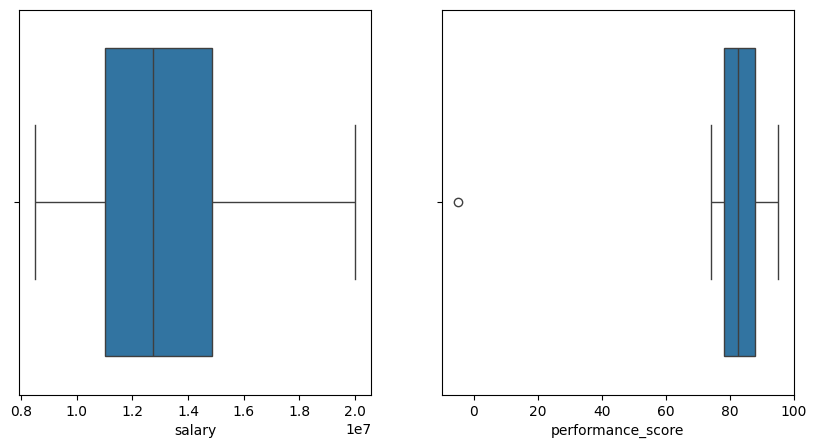

In [23]:
#menggunakan boxplot untuk kolom salary dan performance score
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.boxplot(x=df_employee_clean_enc['salary'], ax=ax[0])
sns.boxplot(x=df_employee_clean_enc['performance_score'], ax=ax[1])
plt.show()

### Pembahasan deteksi outlier pada salary

In [24]:
#pembuktian outliers pada kolom salary
Q1 = df_employee_clean_enc['salary'].quantile(0.25)
Q3 = df_employee_clean_enc['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Kuartil 1 (Q1): {Q1} | Kuartil 3 (Q3) : {Q3} | IQR: {IQR} | Batas Bawah: {lower_bound} | Batas Atas: {upper_bound} \n")

outliers_salary = df_employee_clean_enc[(df_employee_clean_enc['salary'] < lower_bound) | (df_employee_clean_enc['salary'] > upper_bound)]

if outliers_salary.empty:
    print("Tidak ada outlier ditemukan.")
else:
    print("Outliers yang ditemukan:")
    print(outliers_salary)

Kuartil 1 (Q1): 11000000.0 | Kuartil 3 (Q3) : 14875000.0 | IQR: 3875000.0 | Batas Bawah: 5187500.0 | Batas Atas: 20687500.0 

Tidak ada outlier ditemukan.


Temuan dari visualisasi yaitu, kolom salary tidak menunjukkan adanya outlier.Kemudian dilakukan perhitungan untuk deteksi outlier menggunakan nilai Q1 dan Q3 nya. Didapatkan nilai salary masih di dalam rentang Batas bawah dan Batas Atas.



### Pembahasan outliers pada performance score

Pada visualisasi boxplot performance_score ditemukan outlier dan setelah mengidentifikasi lebih lanjut dengan describe(). Ditemukan bahwa terdapat nilai anomali yang di luar batas normal dari data performance_score.

In [25]:
# cek outlier on performance_score
Q1 = df_employee_clean_enc['performance_score'].quantile(0.25)
Q3 = df_employee_clean_enc['performance_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Kuartil 1 (Q1): {Q1} | Kuartil 3 (Q3) : {Q3} | IQR: {IQR} | Batas Bawah: {lower_bound} | Batas Atas: {upper_bound}")


Kuartil 1 (Q1): 78.25 | Kuartil 3 (Q3) : 87.75 | IQR: 9.5 | Batas Bawah: 64.0 | Batas Atas: 102.0


In [26]:
#tampilkan nilai outlier pada performance_score
df_employee_clean_enc[(df_employee_clean_enc['performance_score'] < lower_bound) | (df_employee_clean_enc['performance_score'] > upper_bound)]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing Executive,11000000,2022-08-15,-5,Active,0,0,0,1


Disini saya mengidentifikasi bahwa data ini hanya 3% dari keseluruhan data. Memang termasuk safe to drop, namun karena datanya itu sedikit, maka ini masih perlu pertimbangan lain sebelum ditangani.

Saya menccoba lihat kembali akibat apa saja yang akan terjadi apabila row ini saya drop.

*   Avg_salary akan terkena pengaruh
*   Jumlah karyawan di department Marketing berkurang
*   Nilai rata-rata performance di department marketing juga berubah.

Berdasarkan pada pertimbangan ukuran dataset yang sedikit, posisi dari employee tersebut, dan akibatnya.

Maka saya akan melakukan imputation dengan mengisi data dengan nilai median performance score dari department Marketing.

Karena menurut saya penilaian untuk tiap department akan berbeda sehingga lebih tepat untuk menggunakan nilai median performance score dari tiap department dari employee itu sendiri.

### Penanganan outliers pada performance score

In [27]:
#filter data department marketing
df_employee_clean_enc[df_employee_clean_enc['department_Marketing'] == 1]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing Executive,11000000,2022-08-15,-5,Active,0,0,0,1
8,EMP009,Indah Permata,indah.permata@company.com,6289012345678,Content Writer,9500000,2022-07-20,79,active,0,0,0,1
13,EMP014,Nanda Putra,nanda.putra@company.com,6281444555666,Digital Marketing,11500000,2021-08-20,80,Active,0,0,0,1
17,EMP018,Rizky Fauzan,rizky.fauzan@company.com,6281888999000,Brand Manager,17000000,2019-07-10,94,Active,0,0,0,1
22,EMP023,Winda Sari,winda@company.com,6282333444555,Social Media Specialist,10000000,2022-01-25,78,Active,0,0,0,1
26,EMP027,Amelia Rose,amelia@company.com,82777888999,Event Coordinator,9500000,32-02-2023,79,Active,0,0,0,1


In [28]:
#ubah nilai outlier ke null untuk menghindari terhitungnya ke dalam pencarian nilai median untuk performance score department marketing
df_employee_clean_enc.loc[(df_employee_clean_enc['performance_score'] < lower_bound) | (df_employee_clean_enc['performance_score'] > upper_bound), 'performance_score'] = np.nan

nilai_null = df_employee_clean_enc['performance_score'].isnull().sum()
print(f"Nilai null sekarang = {nilai_null}") #memastikan bahwa nilai outlier sudah diubah ke null


Nilai null sekarang = 1


In [29]:
#isi dengan nilai median dari performance score department marketing
median_performance_score = df_employee_clean_enc[df_employee_clean_enc['department_Marketing'] == 1]['performance_score'].median()

#kolom marketing
kolom_marketing = df_employee_clean_enc.loc[df_employee_clean_enc['department_Marketing'] == 1, 'performance_score']

#isi nilai null dengan median
df_employee_clean_enc.loc[df_employee_clean_enc['department_Marketing'] == 1, 'performance_score'] = kolom_marketing.fillna(median_performance_score)

#cek nilai null sekarang
nilai_null = df_employee_clean_enc['performance_score'].isnull().sum()
print(f"Nilai null setelah diisi dengan median = {nilai_null}") #memastikan bahwa nilai outlier sudah diisi dengan nilai median performance score department marketing


Nilai null setelah diisi dengan median = 0


In [30]:
df_employee_clean_enc[df_employee_clean_enc['department_Marketing'] == 1]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing Executive,11000000,2022-08-15,79.0,Active,0,0,0,1
8,EMP009,Indah Permata,indah.permata@company.com,6289012345678,Content Writer,9500000,2022-07-20,79.0,active,0,0,0,1
13,EMP014,Nanda Putra,nanda.putra@company.com,6281444555666,Digital Marketing,11500000,2021-08-20,80.0,Active,0,0,0,1
17,EMP018,Rizky Fauzan,rizky.fauzan@company.com,6281888999000,Brand Manager,17000000,2019-07-10,94.0,Active,0,0,0,1
22,EMP023,Winda Sari,winda@company.com,6282333444555,Social Media Specialist,10000000,2022-01-25,78.0,Active,0,0,0,1
26,EMP027,Amelia Rose,amelia@company.com,82777888999,Event Coordinator,9500000,32-02-2023,79.0,Active,0,0,0,1


In [31]:
df_employee_clean_enc[df_employee_clean_enc['department_Marketing'] == 1]['performance_score'].describe()

,performance_score
count,6.000000
mean,81.500000
std,6.156298
min,78.000000
25%,79.000000
50%,79.000000
75%,79.750000
max,94.000000


## Challenge

## Pengecekan kembali keseluruhan dataframe sebelum handling challenge

In [32]:
df_employee_clean_enc

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
0,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,Software Engineer,15000000,2022-03-15,85.0,Active,0,0,1,0
1,EMP002,Budi Santoso,budi.santoso@company,6282345678901,Accountant,12000000,2021-06-20,78.0,Active,1,0,0,0
2,EMP003,Citra Dewi,citra.dewi@company.com,83456789012,HR Manager,18000000,2020-01-10,92.0,Active,0,1,0,0
3,EMP004,Dian Pratama,dian.pratama@company.com,6284567890123,Data Analyst,14000000,2023-02-28,88.0,Active,0,0,1,0
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing Executive,11000000,2022-08-15,79.0,Active,0,0,0,1
5,EMP006,Fajar Nugroho,fajar.nugroho@company.com,81234567890,Finance Manager,20000000,2019-04-01,95.0,Active,1,0,0,0
6,EMP007,Gita Sari,gita@company.com,87890123456,Software Engineer,15500000,2021-11-30,82.0,Active,0,0,1,0
7,EMP008,Hendra Kusuma,hendra.kusuma@company.com,88901234567,Recruiter,10000000,2023-05-15,75.0,Active,0,1,0,0
8,EMP009,Indah Permata,indah.permata@company.com,6289012345678,Content Writer,9500000,2022-07-20,79.0,active,0,0,0,1
9,EMP010,Joko Widodo,joko@company.com,6280123456789,DevOps Engineer,16000000,2020-09-10,91.0,Active,0,0,1,0


In [33]:
df_employee_clean_enc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           30 non-null     object 
 1   full_name             30 non-null     object 
 2   email                 30 non-null     object 
 3   phone                 30 non-null     int64  
 4   position              30 non-null     object 
 5   salary                30 non-null     int64  
 6   hire_date             30 non-null     object 
 7   performance_score     30 non-null     float64
 8   status                30 non-null     object 
 9   department_Finance    30 non-null     int64  
 10  department_HR         30 non-null     int64  
 11  department_IT         30 non-null     int64  
 12  department_Marketing  30 non-null     int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 3.3+ KB


### Handle data pada kolom status yang tidak konsisten

In [34]:
#filter status yang tidak konsisten
df_employee_clean_enc[df_employee_clean_enc['status'] != 'Active']

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
8,EMP009,Indah Permata,indah.permata@company.com,6289012345678,Content Writer,9500000,2022-07-20,79.0,active,0,0,0,1
15,EMP016,Putri Ayu,putri@company.com,81666777888,UI/UX Designer,13500000,2022-06-15,83.0,ACTIVE,0,0,1,0


In [35]:
#copy dulu untuk memastikan dataframe sebelumnya tidak termodifikasi
df_employee_clean_enc_challenge = df_employee_clean_enc.copy()
df_employee_clean_enc_challenge[df_employee_clean_enc_challenge['status'] != 'Active']

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
8,EMP009,Indah Permata,indah.permata@company.com,6289012345678,Content Writer,9500000,2022-07-20,79.0,active,0,0,0,1
15,EMP016,Putri Ayu,putri@company.com,81666777888,UI/UX Designer,13500000,2022-06-15,83.0,ACTIVE,0,0,1,0


In [36]:
#handling incosistency
df_employee_clean_enc_challenge['status'] = df_employee_clean_enc_challenge['status'].str.strip().str.capitalize()

#cek kembali nilai unique pada status
df_employee_clean_enc_challenge['status'].unique()

array(['Active'], dtype=object)

Handling yang dilakukan adalah mengubah nilai string yang bukan 'Active' menjadi dalam format capitalize agar semua value berbeda memiliki format yang konsisten.

### Handle data pada kolom phone yang tidak konsisten

In [37]:
#ubah tipe data kolom phone menjadi string, karena nomor telpon juga tidak akan digunakan dalam perhitungan maka akan lebih tepat diubah ke object
df_employee_clean_enc_challenge['phone'] = df_employee_clean_enc_challenge['phone'].astype(str)

In [38]:
df_employee_clean_enc_challenge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           30 non-null     object 
 1   full_name             30 non-null     object 
 2   email                 30 non-null     object 
 3   phone                 30 non-null     object 
 4   position              30 non-null     object 
 5   salary                30 non-null     int64  
 6   hire_date             30 non-null     object 
 7   performance_score     30 non-null     float64
 8   status                30 non-null     object 
 9   department_Finance    30 non-null     int64  
 10  department_HR         30 non-null     int64  
 11  department_IT         30 non-null     int64  
 12  department_Marketing  30 non-null     int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 3.3+ KB


In [39]:
#identifikasi nomor telpon yang tidak berformat 628
df_employee_clean_enc_challenge[df_employee_clean_enc_challenge['phone'].str.len() != 13]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
0,EMP001,Andi Wijaya,andi.wijaya@company.com,81234567890,Software Engineer,15000000,2022-03-15,85.0,Active,0,0,1,0
2,EMP003,Citra Dewi,citra.dewi@company.com,83456789012,HR Manager,18000000,2020-01-10,92.0,Active,0,1,0,0
5,EMP006,Fajar Nugroho,fajar.nugroho@company.com,81234567890,Finance Manager,20000000,2019-04-01,95.0,Active,1,0,0,0
6,EMP007,Gita Sari,gita@company.com,87890123456,Software Engineer,15500000,2021-11-30,82.0,Active,0,0,1,0
7,EMP008,Hendra Kusuma,hendra.kusuma@company.com,88901234567,Recruiter,10000000,2023-05-15,75.0,Active,0,1,0,0
10,EMP011,Kartika Sari,kartika@company.com,81111222333,Accountant,12500000,2021-03-25,84.0,Active,1,0,0,0
12,EMP013,Maya Putri,maya@company.com,81333444555,QA Engineer,13000000,2022-04-10,86.0,Active,0,0,1,0
15,EMP016,Putri Ayu,putri@company.com,81666777888,UI/UX Designer,13500000,2022-06-15,83.0,Active,0,0,1,0
16,EMP017,Qori Amalia,qori@company,87777888999,Training Specialist,10500000,2023-03-20,76.0,Active,0,1,0,0
19,EMP020,Taufik Hidayat,taufik@company.com,82000111222,Financial Analyst,13000000,2022-09-01,81.0,Active,1,0,0,0


In [40]:
# handling nilai berbeda dengan menambahkan 62 didepannya
df_employee_clean_enc_challenge.loc[df_employee_clean_enc_challenge['phone'].str.len() != 13, 'phone'] = '62' + df_employee_clean_enc_challenge['phone']

In [41]:
#cek hasil
df_employee_clean_enc_challenge[df_employee_clean_enc_challenge['phone'].str.len() != 13]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing


Nomor telpon yang tipe data nya tidak sesuai telah diubah ke dalam tipe data object. Kemudian handling data dengan format yang tidak konsisten (tidak sesuai dengan mayoritas yang diawali dengan 62) dilakukan dengan filtering dan menambahkan '62' di awal nilainya

### Validasi format email yang tidak valid

In [42]:
#filter format email yang tidak valid yaitu yang hanya menggunakan satu bagian nama tidak menyertakan nama lengkapnya sehingga tidak sesuai dengan format nama_depan.nama_belakang@company.com
#filter dilakukan dengan membandingkan first_name dan last_namestring yang dipisahkan oleh '.' dengan email

#pisah nama lengkap
first_name = df_employee_clean_enc_challenge['full_name'].str.strip().str.split().str[0].str.lower()
last_name = df_employee_clean_enc_challenge['full_name'].str.strip().str.split().str[1].str.lower()

#format benar
correct_format = first_name + "." + last_name + "@company.com"
#filter dengan perbandingan antara correct format dengan email, tampilkan apabila tidak sesuai dengan correct format
df_employee_clean_enc_challenge[df_employee_clean_enc_challenge['email'] != correct_format]


,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
1,EMP002,Budi Santoso,budi.santoso@company,6282345678901,Accountant,12000000,2021-06-20,78.0,Active,1,0,0,0
4,EMP005,Eka Putri,eka@company.com,6285678901234,Marketing Executive,11000000,2022-08-15,79.0,Active,0,0,0,1
6,EMP007,Gita Sari,gita@company.com,6287890123456,Software Engineer,15500000,2021-11-30,82.0,Active,0,0,1,0
9,EMP010,Joko Widodo,joko@company.com,6280123456789,DevOps Engineer,16000000,2020-09-10,91.0,Active,0,0,1,0
10,EMP011,Kartika Sari,kartika@company.com,6281111222333,Accountant,12500000,2021-03-25,84.0,Active,1,0,0,0
12,EMP013,Maya Putri,maya@company.com,6281333444555,QA Engineer,13000000,2022-04-10,86.0,Active,0,0,1,0
15,EMP016,Putri Ayu,putri@company.com,6281666777888,UI/UX Designer,13500000,2022-06-15,83.0,Active,0,0,1,0
16,EMP017,Qori Amalia,qori@company,6287777888999,Training Specialist,10500000,2023-03-20,76.0,Active,0,1,0,0
18,EMP019,Sinta Dewi,sinta@company.com,6281999000111,Data Scientist,18500000,2021-02-15,90.0,Active,0,0,1,0
19,EMP020,Taufik Hidayat,taufik@company.com,6282000111222,Financial Analyst,13000000,2022-09-01,81.0,Active,1,0,0,0


In [43]:
#handling email yang tidak sesuai dengan format
df_employee_clean_enc_challenge.loc[df_employee_clean_enc_challenge['email'] != correct_format, 'email'] = correct_format

In [44]:
#tampilkan email
df_employee_clean_enc_challenge['email']

,email
0,andi.wijaya@company.com
1,budi.santoso@company.com
2,citra.dewi@company.com
3,dian.pratama@company.com
4,eka.putri@company.com
5,fajar.nugroho@company.com
6,gita.sari@company.com
7,hendra.kusuma@company.com
8,indah.permata@company.com
9,joko.widodo@company.com


Handling format email yang tidak sesuai dengan membuat variabel first_name dan last_name. Variabel ini digunakan untuk membuat correct format yang akan digunakan untuk filtering email dengan format yang invalid. Kemudian email yang invalid diganti dengan email yang formatnya sesuai.

### Handle tanggal yang tidak valid

In [45]:
#ubah tipe data hire_date dari object menjadi datetime
df_employee_clean_enc_challenge['hire_date'] = pd.to_datetime(
    df_employee_clean_enc_challenge['hire_date'], errors='coerce')

#cek hasilnya
df_employee_clean_enc_challenge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   employee_id           30 non-null     object        
 1   full_name             30 non-null     object        
 2   email                 30 non-null     object        
 3   phone                 30 non-null     object        
 4   position              30 non-null     object        
 5   salary                30 non-null     int64         
 6   hire_date             29 non-null     datetime64[ns]
 7   performance_score     30 non-null     float64       
 8   status                30 non-null     object        
 9   department_Finance    30 non-null     int64         
 10  department_HR         30 non-null     int64         
 11  department_IT         30 non-null     int64         
 12  department_Marketing  30 non-null     int64         
dtypes: datetime64[ns](1), float

Tanggal yang tidak valid secara penulisan seperti tanggal 30 Februari dan bulan lebih dari 12 akan menjadi NaT

In [46]:
#setelahnya filter tanggal yang tidak valid
df_employee_clean_enc_challenge[df_employee_clean_enc_challenge['hire_date'].isnull()]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
26,EMP027,Amelia Rose,amelia.rose@company.com,6282777888999,Event Coordinator,9500000,NaT,79.0,Active,0,0,0,1


In [47]:
#handling yang dilakukan adalah dengan mengisi data tangal terakhir di bulan februari
df_employee_clean_enc_challenge.loc[df_employee_clean_enc_challenge['employee_id'] == 'EMP027', 'hire_date'] = pd.to_datetime('2023-02-28')

In [48]:
#cek lagi nilai tanggal yang tidak valid
df_employee_clean_enc_challenge[df_employee_clean_enc_challenge['hire_date'].isnull()]

,employee_id,full_name,email,phone,position,salary,hire_date,performance_score,status,department_Finance,department_HR,department_IT,department_Marketing
